# Topic: Використання клітинних автоматів для моделювання природничих процесів

## Task 1

Реалізувати комп’ютерну модель «Життя». Навести опис даного
клітинного автомату. Представити приклади початкових конфігурацій тих,
що пульсують, та тих, що рухаються.

Завдання 1. Реалізувати комп’ютерну модель «Життя». Покажіть динаміку
зміни станів клітин у грі «Життя», якщо задано наступні правила:
1) до розрахунку беруться 8 сусідів поточної клітини;
2) якщо дві сусідні клітини мають стан 1, стан поточної клітини не
змінюється;
3) якщо три сусідні клітини мають стан 1, стан поточної клітини теж буде
дорівнювати 1. Інакше, стан поточної клітини дорівнює 0.
Нижче наведені приклади деяких початкових початкових конфігурацій.
Серед них є стаціонарні, пульсуючі та рухомі.

In [1]:
import numpy as np
import cv2
import tkinter as tk
from tkinter import ttk
from PIL import Image, ImageTk
import matplotlib.pyplot as plt
import threading
import time
import pandas as pd
from IPython.display import display, Markdown

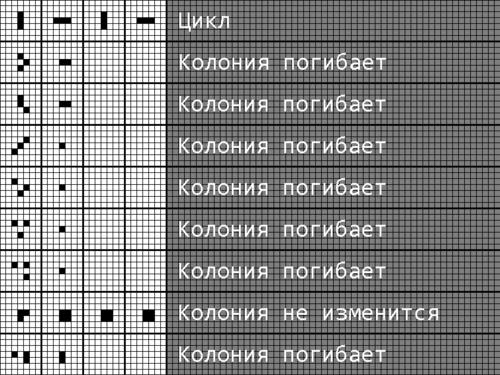

In [2]:
class GameOfLife:
    def __init__(self, root, size=60):
        self.root = root
        self.size = size
        self.grid = np.zeros((size, size), dtype=np.uint8)
        self.cell_size = 8
        self.paused = True
        self.step_count = 0
        self.running = True

        self.neighbors_positions = [
            (-1, -1), (-1, 0), (-1, 1),
            (0, -1),     (0, 1),
            (1, -1),  (1, 0),  (1, 1)
        ]

        self.canvas = tk.Label(root)
        self.canvas.pack()

        tk.Button(root, text="Pause", command=self.pause).pack(fill="x")
        tk.Button(root, text="Random", command=self.add_random).pack(fill="x")
        tk.Button(root, text="Clean", command=self.clear).pack(fill="x")
        tk.Button(root, text="Exit", command=self.exit).pack(fill="x")

        self.new_frame()

    def count_neighbors(self, x, y):
        return sum(
            self.grid[x + dx, y + dy]
            for dx, dy in self.neighbors_positions
            if 0 <= x + dx < self.size and 0 <= y + dy < self.size
        )

    def update(self):
        if not self.paused:
            new_grid = np.zeros_like(self.grid)
            for x in range(self.size):
                for y in range(self.size):
                    n = self.count_neighbors(x, y)
                    current = self.grid[x, y]
                    
                    match (n, current):
                        case (2, 1):   
                            new_grid[x, y] = 1
                        case (3, _):   
                            new_grid[x, y] = 1
                        case _:       
                            new_grid[x, y] = 0
                            
            self.grid = new_grid
            self.step_count += 1

    def draw(self):
        img = np.zeros((self.size * self.cell_size, self.size * self.cell_size, 3), np.uint8)
        for x in range(self.size):
            for y in range(self.size):
                if self.grid[x, y]:
                    cv2.rectangle(img, (y*self.cell_size, x*self.cell_size),
                                  ((y+1)*self.cell_size, (x+1)*self.cell_size),
                                  (255, 255, 255), -1)
        cv2.putText(img, f"Counter: {self.step_count}", (10, 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return ImageTk.PhotoImage(Image.fromarray(img))

    def new_frame(self):
        if not self.running:
            return
        self.update()
        frame = self.draw()

        self.canvas.configure(image=frame)
        self.canvas.image = frame
        self.root.after(80, self.new_frame)

    def pause(self):
        self.paused = not self.paused

    def add_random(self):
        self.grid = np.random.choice([0,1], size=(self.size, self.size), p=[0.85, 0.15]).astype(np.uint8)

    def clear(self):
        self.grid.fill(0)
        self.step_count = 0

    def exit(self):
        self.running = False
        self.root.destroy()

In [3]:
root = tk.Tk()
root.title("Game of Life")
app = GameOfLife(root)
root.mainloop()

## Task 2

2. Реалізувати комп’ютерну модель «Стригучий лишай». Навести опис
даного клітинного автомату. Представити приклади результатів
моделювання з різними ймовірностями зараження клітини.

Реалізувати комп’ютерну модель «Стригучий лишай». Потрібно
змоделювати процес поширення інфекції стригучого лишаю по ділянці шкіри
розміром N × N клітин (N – непарне число). Інфекція починається із центральної
клітини ділянки. У кожний момент часу уражена інфекцією клітина з
ймовірністю 1/2 заражає будь-яку з восьми сусідніх здорових клітин. Через шість
ітерацій моделювання заражена клітина стає несприйнятливою до інфекції
(тримається імунітет), а ще через чотири ітерації – здоровою. У процесі
моделювання потрібно виводити на екран схему ділянки шкіри, відзначаючи
різними кольорами заражені, здорові та несприйнятливі до інфекції клітини.
Підзавданя. Вивести імовірності ураження центральної картинки залежно
від кількості вже уражених сусідніх клітинок. Подати всі обчислення, записати
результати у відповідні таблиці

In [4]:
class RingwormInfection:
    def __init__(self, size=21):
        if size % 2 == 0:
            size += 1
        self.size = size
        self.grid = np.zeros((size, size), dtype=int)
        self.infection_age = np.zeros((size, size), dtype=int)

        center = size // 2
        self.grid[center, center] = 1
        self.infection_age[center, center] = 1

        self.cell_size = 20
        self.window_size = self.size * self.cell_size

        self.stats = {'healthy': [], 'infected': [], 'immune': []}
        self.iteration = 0
        self.running = False
        self.paused = True 

        self.colors = {
    0: (255, 223, 240),  
    1: (221, 204, 240),  
    2: (209, 238, 255)   
}

    def count_neighbors(self, x, y):
        neighbors = []
        positions = [
            (x-1, y-1), (x-1, y), (x-1, y+1),
            (x, y-1),             (x, y+1),
            (x+1, y-1), (x+1, y), (x+1, y+1)
        ]
        
        for nx, ny in positions:
            if 0 <= nx < self.size and 0 <= ny < self.size:
                neighbors.append((nx, ny))
        return neighbors

    def update(self):
        if not self.paused:
            new_grid = self.grid.copy()
            new_age = self.infection_age.copy()

            for x in range(self.size):
                for y in range(self.size):
                    current_state = self.grid[x, y]
                    current_age = self.infection_age[x, y]

                    if current_state == 1:
                        for nx, ny in self.count_neighbors(x, y):
                            if self.grid[nx, ny] == 0 and np.random.random() < 0.5:
                                new_grid[nx, ny] = 1
                                new_age[nx, ny] = 1
                        new_age[x, y] += 1
                        if new_age[x, y] > 6:
                            new_grid[x, y] = 2
                        if new_age[x, y] > 10:
                            new_grid[x, y] = 0
                            new_age[x, y] = 0

                    elif current_state == 2:
                        new_age[x, y] += 1
                        if new_age[x, y] > 10:
                            new_grid[x, y] = 0
                            new_age[x, y] = 0

            self.grid = new_grid
            self.infection_age = new_age
            self.iteration += 1
            self._collect_stats()

    def _collect_stats(self):
        healthy = np.sum(self.grid == 0)
        infected = np.sum(self.grid == 1)
        immune = np.sum(self.grid == 2)
        self.stats['healthy'].append(healthy)
        self.stats['infected'].append(infected)
        self.stats['immune'].append(immune)

    def draw_grid(self):
        img = np.zeros((self.window_size, self.window_size, 3), dtype=np.uint8)
        for x in range(self.size):
            for y in range(self.size):
                state = self.grid[x, y]
                color = self.colors[state]
                start_x = y * self.cell_size
                start_y = x * self.cell_size
                end_x = start_x + self.cell_size
                end_y = start_y + self.cell_size
                cv2.rectangle(img, (start_x, start_y), (end_x, end_y), color, -1)
        return img

    def reset(self):
        self.grid = np.zeros((self.size, self.size), dtype=int)
        self.infection_age = np.zeros((self.size, self.size), dtype=int)
        center = self.size // 2
        self.grid[center, center] = 1
        self.infection_age[center, center] = 1
        self.stats = {'healthy': [], 'infected': [], 'immune': []}
        self.iteration = 0
        self.paused = True

In [5]:
class RingwormTk:
    def __init__(self, root, model):
        self.root = root
        self.model = model
        self.root.geometry(f"{model.window_size+250}x{model.window_size+50}") 
        self.root.resizable(False, False)

        self.canvas = tk.Label(root)
        self.canvas.place(x=10, y=10)

        control_frame = tk.Frame(root, bg="#1e1e1e")
        control_frame.place(x=model.window_size + 30, y=20)

        ttk.Button(control_frame, text="Start", command=self.start_or_resume).pack(pady=5)
        ttk.Button(control_frame, text="Pause", command=self.toggle_pause).pack(pady=5)
        ttk.Button(control_frame, text="Reopen", command=self.reset_model).pack(pady=5)
        ttk.Button(control_frame, text="Plot", command=self.show_stats).pack(pady=5)
        ttk.Button(control_frame, text="Exit", command=self.exit_app).pack(pady=5)


        threading.Thread(target=self.run_loop, daemon=True).start()
        self.update_display()

    def start_or_resume(self):
        self.model.running = True
        self.model.paused = False

    def toggle_pause(self):
        self.model.paused = not self.model.paused

    def reset_model(self):
        self.model.reset()

    def exit_app(self):
        self.model.running = False
        self.root.destroy()

    def show_stats(self):
        if len(self.model.stats['healthy']) == 0:
            return
        plt.figure(figsize=(7, 4))
        t = range(len(self.model.stats['healthy']))
        plt.plot(t, self.model.stats['healthy'], 'g', label="healthy")
        plt.plot(t, self.model.stats['infected'], 'r', label="infected")
        plt.plot(t, self.model.stats['immune'], 'y', label="immune")
        plt.xlabel("iteration")
        plt.ylabel("count")
        plt.legend()
        plt.grid(True)
        plt.show()

    def run_loop(self):
        while True:
            if self.model.running and not self.model.paused:
                self.model.update()
            time.sleep(0.2)

    def update_display(self):
        img = self.model.draw_grid()
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_pil = Image.fromarray(img_rgb)
        img_tk = ImageTk.PhotoImage(img_pil)
        self.canvas.config(image=img_tk)
        self.canvas.image = img_tk
        self.root.after(100, self.update_display)

In [6]:
if __name__ == "__main__":
    root = tk.Tk()
    model = RingwormInfection(size=25)
    app = RingwormTk(root, model)
    root.mainloop()

Підзавданя. Вивести імовірності ураження центральної картинки залежно
від кількості вже уражених сусідніх клітинок. Подати всі обчислення, записати
результати у відповідні таблиці



$$P(\text{сусіди не інфікують}) = q^k = (1/2)^k$$



$$P(\text{уражено центр}) = 1 - P(\text{не інфіковано}) = 1 - (1/2)^k$$

In [7]:
max_neighbors = 8

ver = 0.5
anti = 1 - ver

data = []
for k in range(1, max_neighbors + 1):
    probility = anti ** k

    prob_infected = 1 - probility

    denominator = 2 ** k
    numerator = denominator - 1
    prob_fraction = f"{numerator}/{denominator}"

    data.append({
        'k ': k,
        'P(Уражено)': prob_fraction,
        'P(Уражено) ': prob_infected,
    })
df = pd.DataFrame(data)

df['P(Уражено)'] = df['P(Уражено)'].round(4)

display(Markdown(f'Ймовірність зараження від сусіда $p = {ver}$.'))
display(df)

Ймовірність зараження від сусіда $p = 0.5$.

,k,P(Уражено),P(Уражено)
0,1,1/2,0.500000
1,2,3/4,0.750000
2,3,7/8,0.875000
3,4,15/16,0.937500
4,5,31/32,0.968750
5,6,63/64,0.984375
6,7,127/128,0.992188
7,8,255/256,0.996094


## Task 3

3. Реалізувати комп’ютерну модель «Розповсюдження лісової пожежі».
Навести опис даного клітинного автомату. Представити приклади
результатів моделювання з різними ймовірностями початку горіння.

Реалізувати комп’ютерну модель
«Розповсюдження лісової пожежі».
Для моделювання лісової пожежі можна
використовувати наступні правила:
1) клітини можуть бути в трьох станах: 0 –
порожня область, 1 – палаюча область, 2 –
область лісу;
2) якщо один або більше з 4-х сусідів має
палаючий стан, а сама клітина є областю
лісу, новий її стан буде дорівнювати 1;
3) існує дуже мала ймовірність (візьмемо
0,000005) того, що клітина лісу (стан 2) починає горіти сама по собі
(наприклад, від блискавки);
4) клітина, що горить, стає порожньою (стан 0);
5) існує невелика ймовірність (візьмемо 0,01) того, що порожня клітина стає
лісом для моделювання росту.

In [8]:
class ForestFireModel:
    def __init__(self, size=80, fire=0.00005, grow=0.01):
        self.size = size
        self.fire = fire
        self.grow = grow

        self.running = False
        self.paused = False

        self.generation = 0
        self.cell_size = 8
        self.window_size = size * self.cell_size

        self.grid = np.zeros((size, size), dtype=int)
        self.random(0.65)

        self.colors = {
        0:  (189, 240, 255),  # FFF0BD 
        1: (70, 0, 229),     # E50046 
        2: (156, 219, 199)   # C7DB9C 
         }


    def random(self, density):
        self.grid = np.random.choice([0, 2], size=(self.size, self.size), p=[1 - density, density])

    def start_fire(self, x=None, y=None):
        if x is None:
            x = self.size // 2
        if y is None:
            y = self.size // 2

        if 0 <= x < self.size and 0 <= y < self.size:
            self.grid[x, y] = 1



    def count_fire_neighbors(self, r, c):
        for dr, dc in [(-1,0), (1,0), (0,-1), (0,1)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < self.size and 0 <= nc < self.size:
                if self.grid[nr, nc] == 1:
                    return True
        return False
    

    def update(self):
        if self.paused or not self.running:
            return
        
        new_grid = self.grid.copy()

        for r in range(self.size):
            for c in range(self.size):
                s = self.grid[r, c]
                if s == 2:
                    if self.count_fire_neighbors(r, c) or np.random.rand() < self.fire:
                        new_grid[r, c] = 1
                elif s == 1:
                    new_grid[r, c] = 0
                elif s == 0:
                    if np.random.rand() < self.grow:
                        new_grid[r, c] = 2
        self.grid = new_grid
        self.generation += 1

    def draw_grid(self):
        img = np.zeros((self.window_size, self.window_size, 3), dtype=np.uint8)
        for x in range(self.size):
            for y in range(self.size):
                color = self.colors[self.grid[x, y]]
                cv2.rectangle(img,
                              (y * self.cell_size, x * self.cell_size),
                              ((y + 1) * self.cell_size, (x + 1) * self.cell_size),
                              color, -1)
        return img

    def reset(self):
        self.generation = 0
        self.random(0.65)
        self.start_fire()

In [9]:

class ForestFireTk:
    def __init__(self, root, model):
        self.root = root
        self.model = model
        self.root.geometry(f"{model.window_size+300}x{model.window_size+50}")
        self.root.resizable(False, False)

        self.canvas = tk.Label(root)
        self.canvas.place(x=10, y=10)

        control_frame = tk.Frame(root, bg="#1e1e1e")
        control_frame.place(x=model.window_size + 20, y=10)

        ttk.Button(control_frame, text="Start", command=self.start_or_resume).pack(pady=5)
        ttk.Button(control_frame, text="Pause", command=self.toggle_pause).pack(pady=5)
        ttk.Button(control_frame, text="Reset", command=self.reset_model).pack(pady=5)
        ttk.Button(control_frame, text="Exit", command=self.exit_app).pack(pady=5)

        ttk.Label(control_frame, text="ймовірність вогня").pack(pady=(20,0))
        self.lightning_slider = ttk.Scale(control_frame, from_=0.00001, to=0.01, value=model.fire, orient='horizontal', command=self.update_lightning)
        self.lightning_slider.pack(pady=5, fill='x')

        ttk.Label(control_frame, text="рост лісу").pack(pady=(10,0))
        self.growth_slider = ttk.Scale(control_frame, from_=0.001, to=0.1, value=model.grow, orient='horizontal', command=self.update_growth)
        self.growth_slider.pack(pady=5, fill='x')

        threading.Thread(target=self.run_loop, daemon=True).start()
        self.update_display()

    def start_or_resume(self):
        self.model.running = True
        self.model.paused = False
        self.model.start_fire()

    def toggle_pause(self):
        self.model.paused = not self.model.paused

    def reset_model(self):
        self.model.reset()

    def exit_app(self):
        self.model.running = False
        self.root.destroy()

    def update_lightning(self, value):
        self.model.fire = float(value)

    def update_growth(self, value):
        self.model.grow = float(value)

    def run_loop(self):
        while True:
            if self.model.running and not self.model.paused:
                self.model.update()
            time.sleep(0.1)

    def update_display(self):
        img = self.model.draw_grid()
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_pil = Image.fromarray(img_rgb)
        img_tk = ImageTk.PhotoImage(img_pil)
        self.canvas.config(image=img_tk)
        self.canvas.image = img_tk
        self.root.after(100, self.update_display)


In [10]:
if __name__ == "__main__":
    root = tk.Tk()
    model = ForestFireModel(size=80)
    app = ForestFireTk(root, model)
    root.mainloop()


invalid command name "5719113408update_display"
    while executing
"5719113408update_display"
    ("after" script)
